# Thermostat Experiment Analysis

This notebook demonstrates how to analyze thermostat experiment results using the modular analysis functions.

## Setup

In [1]:
import sys
sys.path.insert(0, '/workspaces/CUBES/beizaee')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import analysis functions
from analysis.shared import load_run_csv
from analysis.shared.constants import (
    ROOM_MAPPING,
    FLOOR_AREAS,
    BEIZAEE_REFERENCE,
    CONTROL_COLORS
)
from analysis.thermostat import (
    compare_room_temperatures,
    compute_temperature_deltas,
    compare_gas_consumption,
    boiler_efficiency,
    daily_summary,
    calculate_kwh_per_day
)
from analysis.thermostat.plotting import (
    plot_boiler_config_comparison,
    plot_absolute_temperatures_with_beizaee_period,
    plot_gas_consumption_by_config,
    plot_daily_gas_consumption,
)

print("✓ Imports successful")

✓ Imports successful


## Load Simulation Results

Point to your experiment output directory:

In [3]:
from pathlib import Path

def load_run(path):
    p=Path(path)
    if not p.exists(): raise FileNotFoundError(f"Missing: {p}")
    df=load_run_csv(str(p))
    print(f"Loaded {p.parent.name}: {len(df)} rows, {len(df.columns)} cols, {df.index[0]} → {df.index[-1]}")
    return df

base=Path("/workspaces/CUBES/beizaee/experiments/thermostat/runs_validation/beizaee")
df_conv=load_run(base/"conventional_control__part_2__eff_quadratic"/"eplusout.csv")
df_zonal=load_run(base/"zonal_control__part_2__eff_quadratic"/"eplusout.csv")
df_occ=load_run(base/"occupancy_control__part_2__eff_quadratic"/"eplusout.csv")

# Create results dictionary for plot_boiler_config_comparison
results = {
    "conventional_control__part_2__eff_quadratic": df_conv,
    "zonal_control__part_2__eff_quadratic": df_zonal,
    "occupancy_control__part_2__eff_quadratic": df_occ,
}


Loaded conventional_control__part_2__eff_quadratic: 8008 rows, 365 cols, 2013-02-16 00:10:00 → 2013-04-21 23:50:00
Loaded zonal_control__part_2__eff_quadratic: 8008 rows, 365 cols, 2013-02-16 00:10:00 → 2013-04-21 23:50:00
Loaded occupancy_control__part_2__eff_quadratic: 8008 rows, 365 cols, 2013-02-16 00:10:00 → 2013-04-21 23:50:00


,Conventional,Zonal,Occupancy
Part-load: 2 Eff. Curve: quadratic,60.04,54.06,47.5


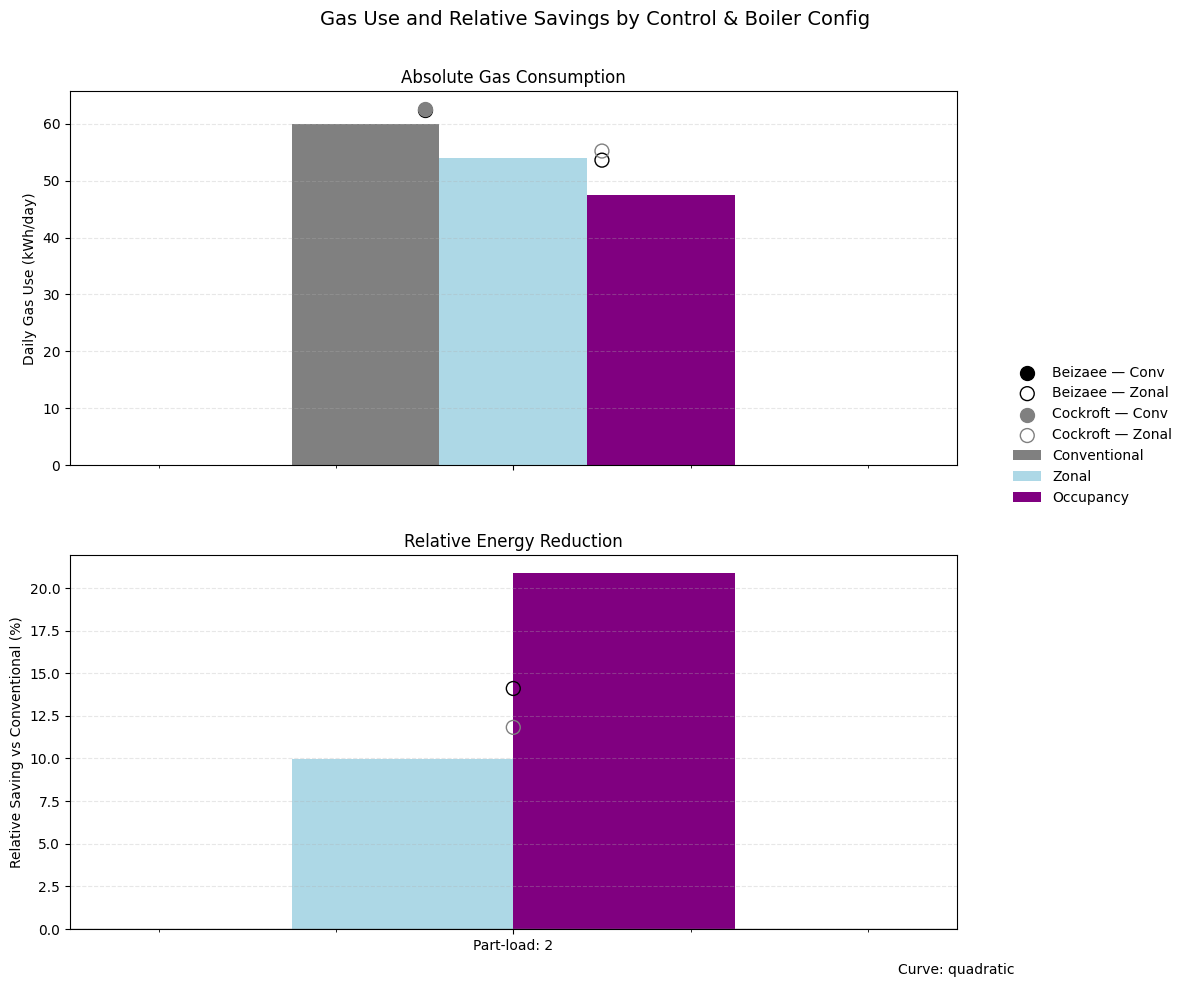

In [6]:
plot_gas_consumption_by_config(
    results,
    controls=["conventional_control", "zonal_control", "occupancy_control"],
    show_references=True)


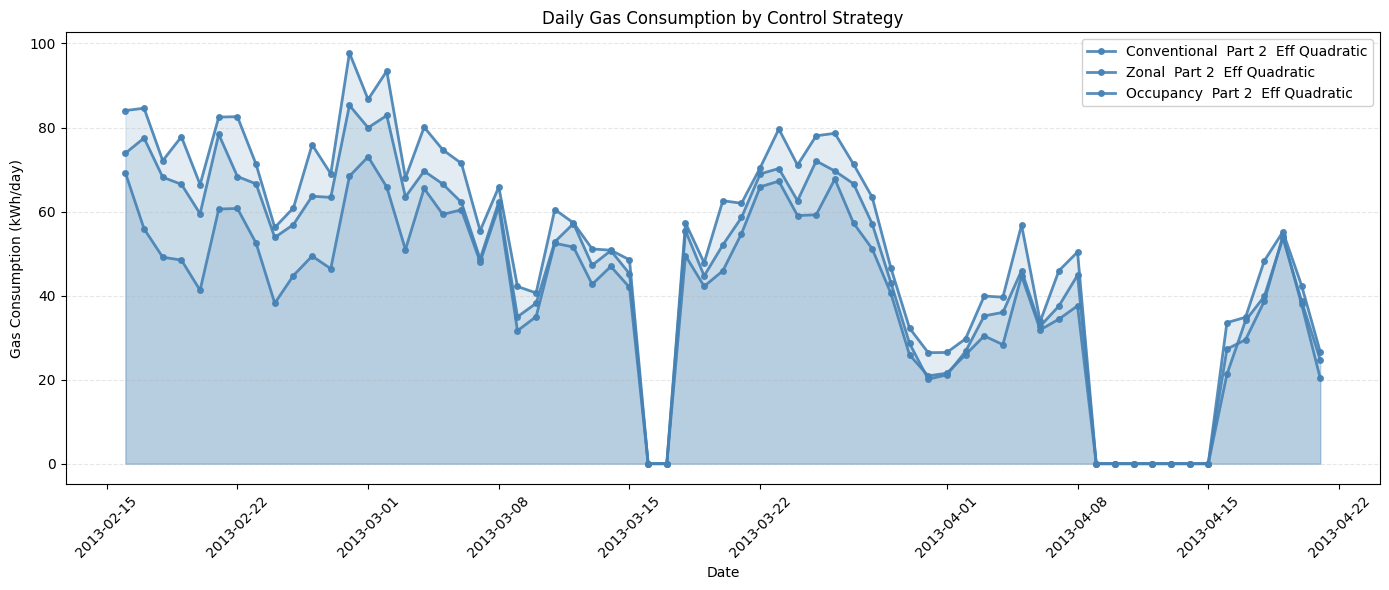

In [7]:
fig, ax = plot_daily_gas_consumption(results)
plt.show()

### TODO Integrate holdiays:

"H28": [
            (1, 2),
            (2, 17),
            (2, 18),
            (2, 19),
            (2, 20),
            (2, 21),
            (2, 22),
            (2, 23),
            (2, 24),
            (2, 25),
            (2, 26),
            (2, 27),
            (2, 28),
            (3, 1),
            (3, 2),
            (3, 3),
        ],

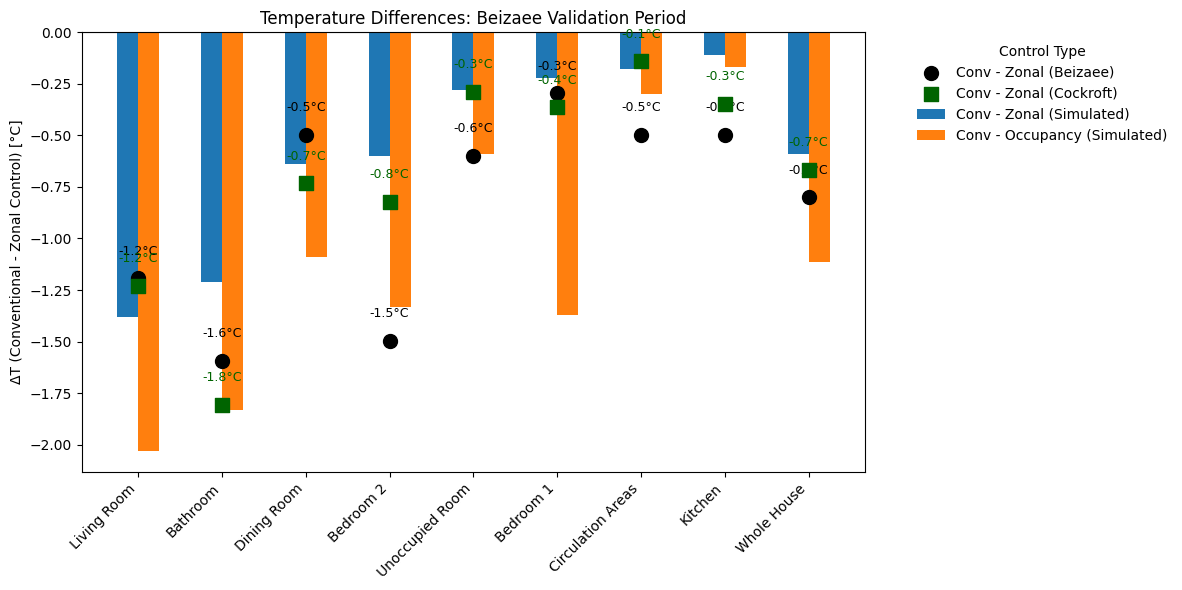

In [8]:

# Plot temperature differences (Conventional - Smart Controls)
# This shows how much warmer/cooler conventional control is compared to zonal/occupancy
fig, ax = plot_boiler_config_comparison(
    results_dict=results,
    config_tag="part_2__eff_quadratic",  # Filter to this boiler config
    room_mapping=ROOM_MAPPING,
    controls=["conventional_control", "zonal_control", "occupancy_control"],  # Add "occupancy_control" when available
    run_label="Beizaee Validation Period"
)
plt.show()

